koneksi ke google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


import library

In [ ]:
import os
import hashlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm
from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import joblib

load dataset google drive ke collab,looping juga buat preprocessing (resize (64x64), grayscale, dan FE nya pake HOG)

In [ ]:
base_path = "/content/drive/MyDrive/dataset"

categories = ["Kosong", "Terisi", "Penuh"]

X = []
y = []

for label, category in enumerate(categories):
    path = os.path.join(base_path, category)

    for filename in tqdm(os.listdir(path), desc=category):
        if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(path, filename)
            img = cv2.imread(img_path)

            if img is not None:
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                gray = cv2.resize(gray, (64, 64))

                features = hog(
                    gray,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    block_norm='L2-Hys'
                )

                X.append(features)
                y.append(label)

X = np.array(X)
y = np.array(y)

Penuh: 100%|██████████| 2500/2500 [01:13<00:00, 33.79it/s]


bikin pipeline buat standar scaler dan model svm-nya

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

ini parameter yang akan dicoba sama gridsearchcv buat nyari parameter c dan gamma terbaik dari svmnya

In [ ]:
param_grid = {
    "svm__C": [0.001, 0.1, 1, 10],
    "svm__kernel": ["rbf", "linear"],
    "svm__gamma": ["scale"]
    # "svm__gamma": ["auto"]
}

proses Starified KFold dan GridSearchCV-nya

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid.fit(X, y)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.001, 0.1, 1, 10], 'svm__gamma': ['scale'],
                         'svm__kernel': ['rbf', 'linear']},
             return_train_score=True, scoring='accuracy', verbose=1)

tampilin semua result dari gridsearchcv nya dari nilai c, gamma, skor training, dan skor testing

In [ ]:
results = pd.DataFrame(grid.cv_results_)

results[['param_svm__C', 'param_svm__gamma',
         'mean_train_score', 'mean_test_score']]

,param_svm__C,param_svm__gamma,mean_train_score,mean_test_score
0,0.001,scale,0.628367,0.610933
1,0.001,scale,0.820667,0.730400
2,0.100,scale,0.736033,0.694000
3,0.100,scale,0.944000,0.677200
4,1.000,scale,0.950400,0.813733
5,1.000,scale,0.995933,0.640667
6,10.000,scale,1.000000,0.812267
7,10.000,scale,1.000000,0.636533


sorting terbesar menurut skor testing

In [ ]:
cols = ["mean_test_score", "mean_train_score", "param_svm__C", "param_svm__gamma", "param_svm__kernel",]
print(results[cols].sort_values(by="mean_test_score", ascending=False).head(3))

   mean_test_score  mean_train_score  param_svm__C param_svm__gamma  \
4         0.813733          0.950400         1.000            scale   
6         0.812267          1.000000        10.000            scale   
1         0.730400          0.820667         0.001            scale   

  param_svm__kernel  
4               rbf  
6               rbf  
1            linear  


pilih parameter terbaik dan skor akurasi terbaiknya

In [ ]:
print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_ * 100)

Best Params: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV Accuracy: 81.37333333333332


confusion matrix

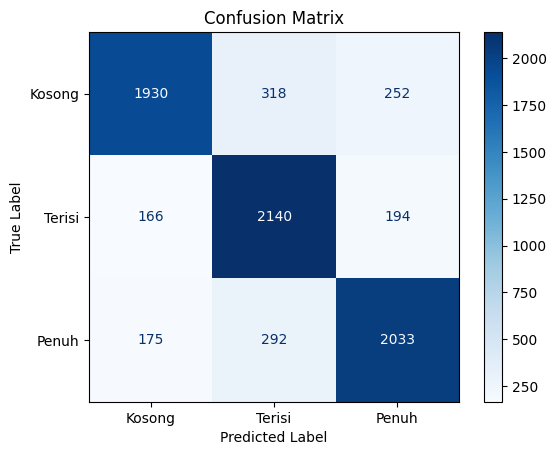

In [ ]:
y_pred = cross_val_predict(grid.best_estimator_, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

classification report

In [ ]:
# y_pred = cross_val_predict(grid.best_estimator_, X, y, cv=cv)

print("Accuracy:", accuracy_score(y, y_pred) * 100)
print(classification_report(y, y_pred, target_names=categories))

Accuracy: 81.37333333333333
              precision    recall  f1-score   support

      Kosong       0.85      0.77      0.81      2500
      Terisi       0.78      0.86      0.82      2500
       Penuh       0.82      0.81      0.82      2500

    accuracy                           0.81      7500
   macro avg       0.82      0.81      0.81      7500
weighted avg       0.82      0.81      0.81      7500



simpan model buat di streamlit nanti

In [ ]:
saved_data = {
    'model': grid.best_estimator_,
    'categories': ["Kosong", "Terisi", "Penuh"]
}
joblib.dump(saved_data, 'model_svm_hog.joblib')

['model_svm_hog.joblib']